# Level 3 - Task 2

## Customer Preference Analysis

### Objective

Analyze the relationship between cuisine type and restaurant ratings, identify the most popular cuisines based on customer votes, and determine which cuisines tend to receive higher ratings.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Dataset .csv")

In [3]:
df = pd.read_csv("Dataset .csv")

In [4]:
df = df.dropna(subset=['Cuisines'])

print(df.shape)

(9542, 21)


In [5]:
cuisine_rating = (
    df.groupby("Cuisines")
    ["Aggregate rating"]
    .mean()
    .sort_values(ascending=False)
)

print(cuisine_rating.head(10))

Cuisines
Burger, Bar Food, Steak            4.9
American, Burger, Grill            4.9
American, Caribbean, Seafood       4.9
American, Coffee and Tea           4.9
Mexican, American, Healthy Food    4.9
Italian, Bakery, Continental       4.9
BBQ, Breakfast, Southern           4.9
European, German                   4.9
Hawaiian, Seafood                  4.9
Sunda, Indonesian                  4.9
Name: Aggregate rating, dtype: float64


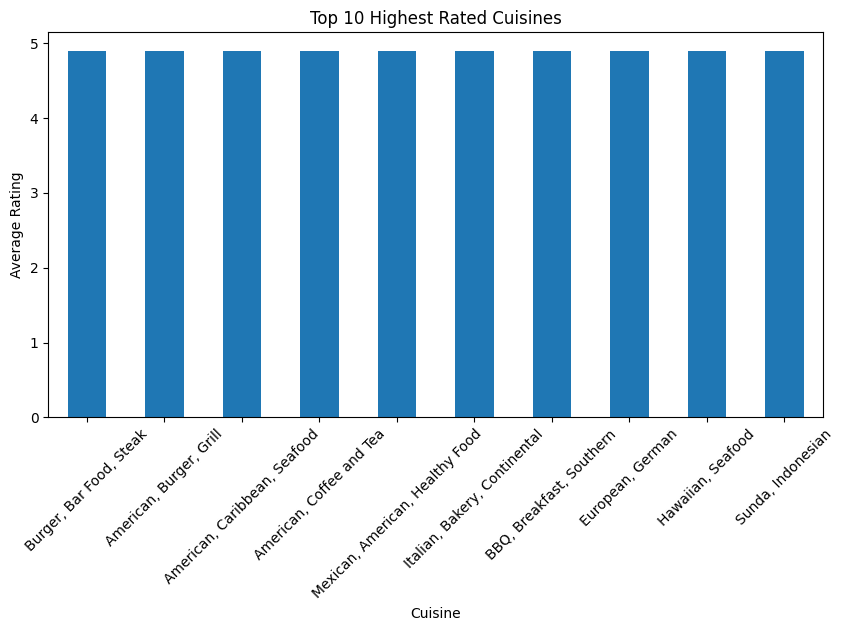

In [6]:
top_rated_cuisines = cuisine_rating.head(10)

top_rated_cuisines.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Highest Rated Cuisines")
plt.xlabel("Cuisine")
plt.ylabel("Average Rating")

plt.xticks(rotation=45)

plt.show()

In [7]:
cuisine_votes = (
    df.groupby("Cuisines")
    ["Votes"]
    .sum()
    .sort_values(ascending=False)
)

print(cuisine_votes.head(10))

Cuisines
North Indian, Mughlai             53747
North Indian                      46241
North Indian, Chinese             42012
Cafe                              30657
Chinese                           21925
North Indian, Mughlai, Chinese    20115
Fast Food                         17852
South Indian                      16433
Mughlai, North Indian             15275
Italian                           14799
Name: Votes, dtype: int64


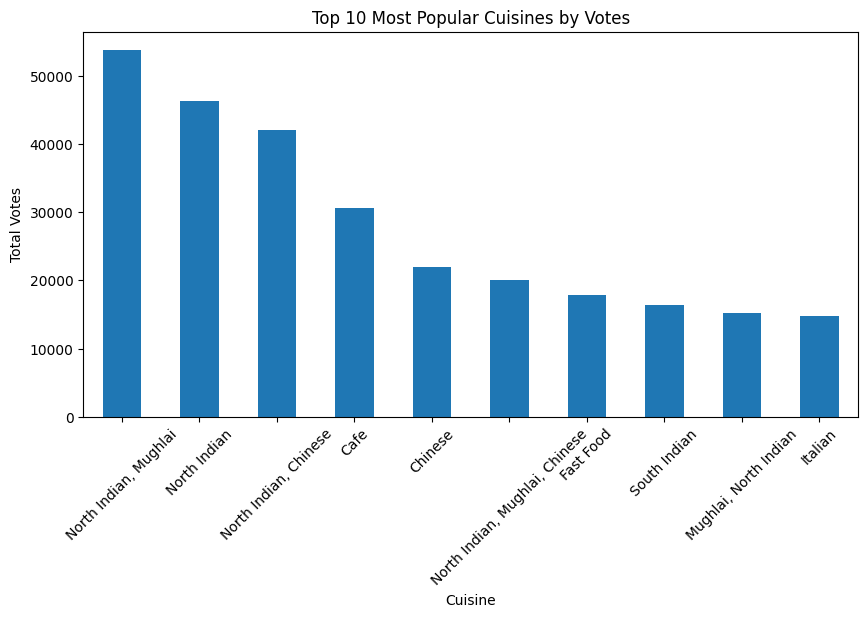

In [8]:
top_voted_cuisines = cuisine_votes.head(10)

top_voted_cuisines.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Most Popular Cuisines by Votes")
plt.xlabel("Cuisine")
plt.ylabel("Total Votes")

plt.xticks(rotation=45)

plt.show()

In [9]:
cuisine_analysis = (
    df.groupby("Cuisines")
    .agg({
        "Aggregate rating":"mean",
        "Votes":"sum"
    })
)

cuisine_analysis = cuisine_analysis.sort_values(
    by="Aggregate rating",
    ascending=False
)

print(cuisine_analysis.head(10))

                                 Aggregate rating  Votes
Cuisines                                                
Burger, Bar Food, Steak                       4.9   2238
American, Burger, Grill                       4.9    162
American, Caribbean, Seafood                  4.9    548
American, Coffee and Tea                      4.9    570
Mexican, American, Healthy Food               4.9    223
Italian, Bakery, Continental                  4.9    322
BBQ, Breakfast, Southern                      4.9    249
European, German                              4.9   1413
Hawaiian, Seafood                             4.9   1343
Sunda, Indonesian                             4.9   5514


In [10]:
cuisine_analysis.head(10)

,Aggregate rating,Votes
Cuisines,,
"Burger, Bar Food, Steak",4.9,2238
"American, Burger, Grill",4.9,162
"American, Caribbean, Seafood",4.9,548
"American, Coffee and Tea",4.9,570
"Mexican, American, Healthy Food",4.9,223
"Italian, Bakery, Continental",4.9,322
"BBQ, Breakfast, Southern",4.9,249
"European, German",4.9,1413
"Hawaiian, Seafood",4.9,1343


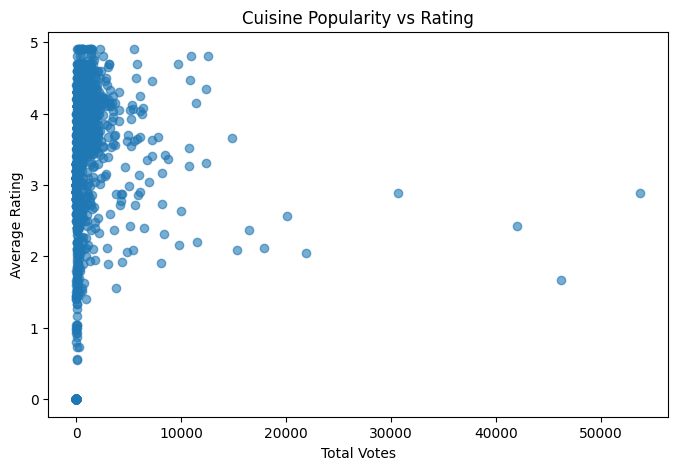

In [11]:
plt.figure(figsize=(8,5))

plt.scatter(
    cuisine_analysis["Votes"],
    cuisine_analysis["Aggregate rating"],
    alpha=0.6
)

plt.xlabel("Total Votes")
plt.ylabel("Average Rating")
plt.title("Cuisine Popularity vs Rating")

plt.show()

In [12]:

high_rated_popular = cuisine_analysis.sort_values(
    by=["Aggregate rating","Votes"],
    ascending=False
)

print(high_rated_popular.head(10))

                         Aggregate rating  Votes
Cuisines                                        
Sunda, Indonesian                     4.9   5514
Burger, Bar Food, Steak               4.9   2238
American, Sandwich, Tea               4.9   1457
Italian, Deli                         4.9   1424
European, German                      4.9   1413
Hawaiian, Seafood                     4.9   1343
American, BBQ, Sandwich               4.9   1252
Mughlai, Lucknowi                     4.9   1057
Continental, Indian                   4.9    641
European, Asian, Indian               4.9    621
